# User Behaviour Analysis

In [8]:
import nbimport 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from events_EDA import safe_tz_convert, to_hour, time_str_to_hour

# Load the dataset
new_data = pd.read_csv('new_data.csv')

# Summary Statistics plot

=== OVERRIDE EVENTS EXTRACTED ===
Total override events: 44
Houses: 1  |  Zones: ['Zone 1', 'Zone 2']

=== BEHAVIOURAL SUMMARY ===
 house_id   zone  n_overrides  overrides_per_week avg_start_fmt  avg_duration_h  avg_temp_difference    pct_up  pct_down
    29962 Zone 1           22                 1.2         13:28        6.480644             0.068182 36.363636 63.636364
    29962 Zone 2           22                 1.2         12:52        6.675884             0.431818 54.545455 31.818182


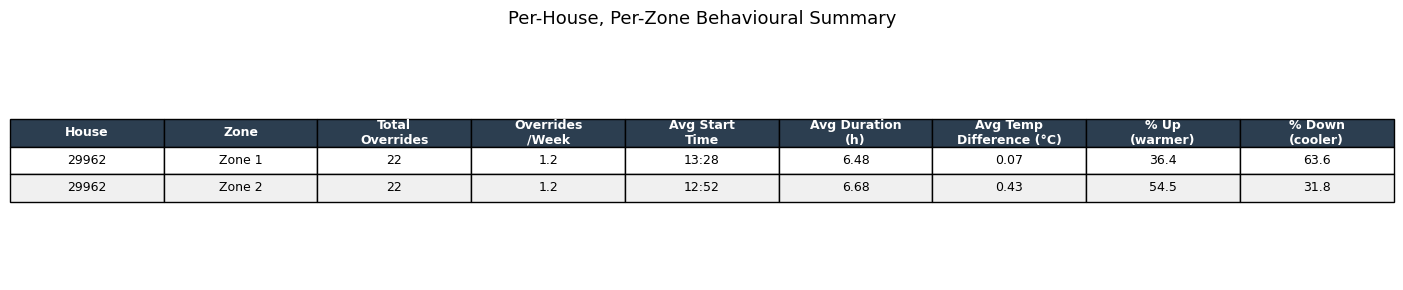

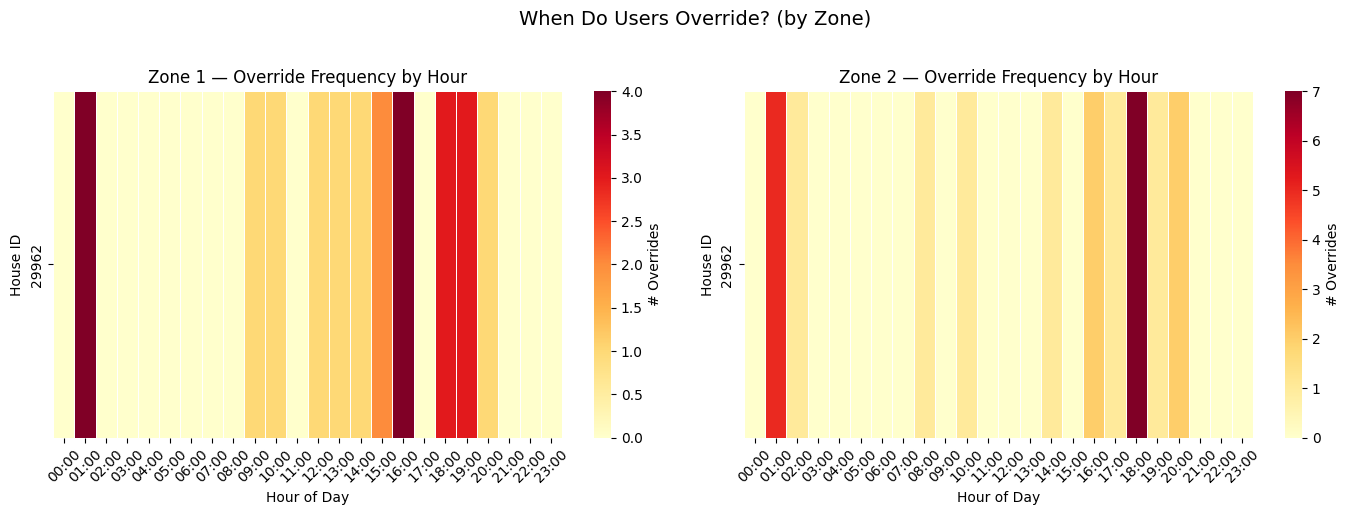

/var/folders/q6/r1x78lxs4711rsxwpp0jly9h0000gp/T/ipykernel_72036/4064580682.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="zone", y="temp_difference", palette=palette,
/var/folders/q6/r1x78lxs4711rsxwpp0jly9h0000gp/T/ipykernel_72036/4064580682.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x="zone", y="temp_difference", palette=palette,


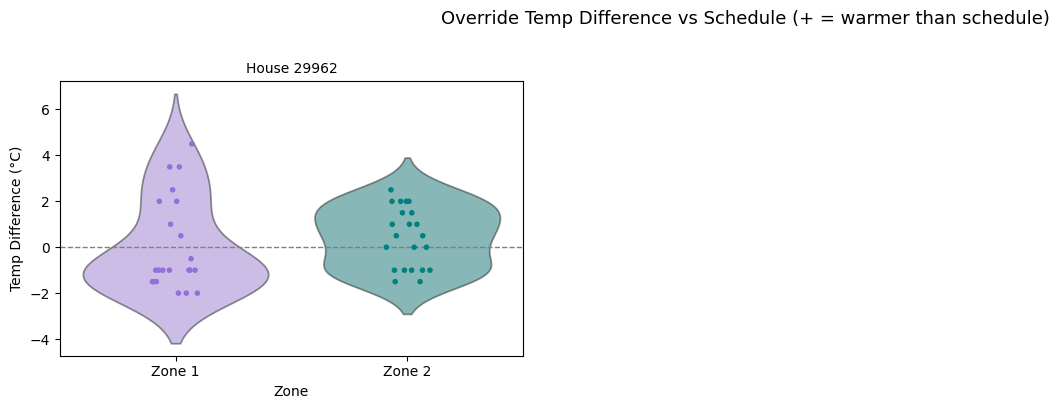

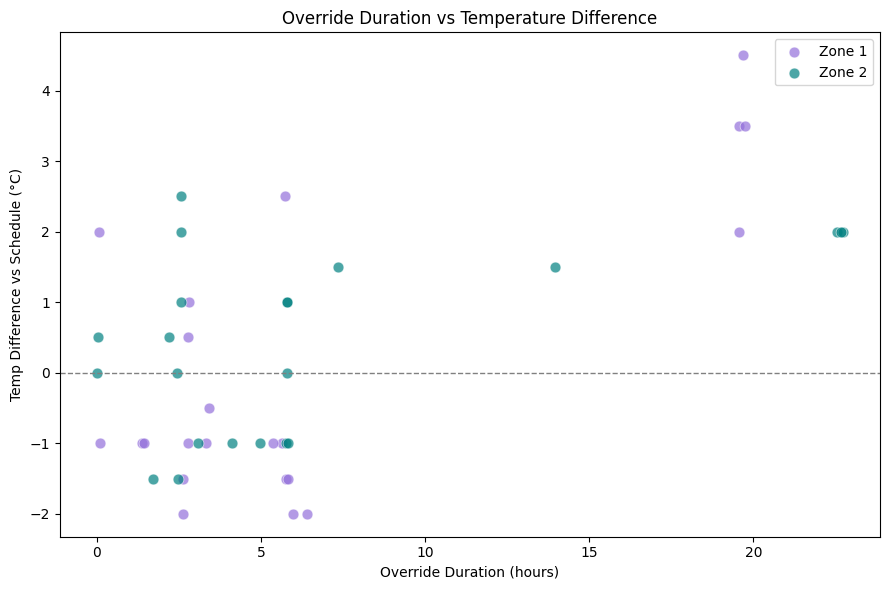

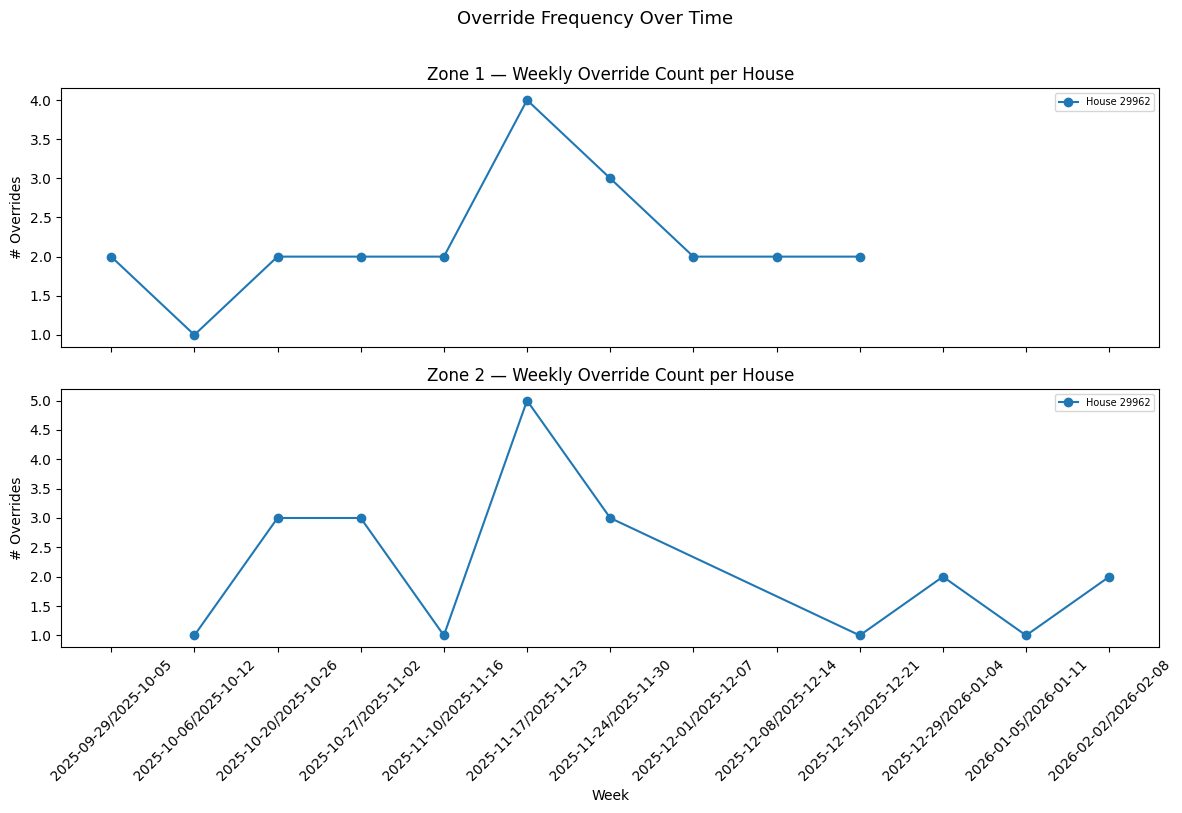

In [ ]:
# Build override-level dataframe 

def build_override_df(data):
    """
    Extract one row per override event with:
        house_id, zone, date, start_hour, end_hour, duration_h,
        override_temp, scheduled_temp_at_start, temp_difference
    """
    data = data.copy()

    # Timezone-aware Timestamp
    data["Timestamp"] = pd.to_datetime(data["Timestamp"], errors="coerce")
    if data["Timestamp"].dt.tz is None:
        data["Timestamp"] = data["Timestamp"].dt.tz_localize("UTC")
    else:
        data["Timestamp"] = data["Timestamp"].dt.tz_convert("UTC")

    data["override_end"] = safe_tz_convert(data["override_end"])

    # Normalise zone to string so "1.0" / 1 / "1" all become "Zone 1"
    data["zone"] = data["zone"].apply(
        lambda z: f"Zone {int(float(z))}" if pd.notna(z) else "Zone ?"
    )

    # Only keep override rows
    override_rows = data[data["override_end"].notna() & data["C"].notna()].copy()
    override_rows["start_hour"] = to_hour(override_rows["Timestamp"])
    override_rows["end_hour"]   = to_hour(override_rows["override_end"])
    override_rows.loc[
        override_rows["end_hour"] < override_rows["start_hour"], "end_hour"
    ] = 23.99
    override_rows["duration_h"] = override_rows["end_hour"] - override_rows["start_hour"]
    override_rows["date"] = override_rows["Timestamp"].dt.date

    # For each override, look up what the schedule said at that time
    schedule_rows = data[data["time"].notna() & data["C"].notna()].copy()

    def get_scheduled_temp(house, zone, date, start_hour):
        sched = schedule_rows[
            (schedule_rows["house_id"] == house) &
            (schedule_rows["zone"] == zone) &
            (schedule_rows["Timestamp"].dt.date == date)
        ].copy()
        if sched.empty:
            return np.nan
        sched["t_hour"] = time_str_to_hour(sched["time"])
        sched = sched.sort_values("t_hour")
        valid = sched[sched["t_hour"] <= start_hour]
        if valid.empty:
            return sched.iloc[0]["C"]
        return valid.iloc[-1]["C"]

    override_rows["scheduled_temp"] = override_rows.apply(
        lambda r: get_scheduled_temp(r["house_id"], r["zone"], r["date"], r["start_hour"]),
        axis=1
    )
    override_rows["temp_difference"] = override_rows["C"] - override_rows["scheduled_temp"]

    return override_rows[[
        "house_id", "zone", "date", "start_hour", "end_hour",
        "duration_h", "C", "scheduled_temp", "temp_difference"
    ]].rename(columns={"C": "override_temp"})


# Per-house, per-zone summary stats 

def summarise_behaviour(ov):
    summary = (
        ov.groupby(["house_id", "zone"])
        .agg(
            n_overrides        = ("override_temp", "count"),
            avg_start_hour     = ("start_hour",    "mean"),
            std_start_hour     = ("start_hour",    "std"),
            avg_duration_h     = ("duration_h",    "mean"),
            avg_temp_difference     = ("temp_difference",    "mean"),
            pct_up             = ("temp_difference",    lambda x: (x > 0).mean() * 100),
            pct_down           = ("temp_difference",    lambda x: (x < 0).mean() * 100),
            most_common_hour   = ("start_hour",    lambda x: round(x.mode()[0], 1)),
        )
        .reset_index()
    )
    summary["avg_start_fmt"] = summary["avg_start_hour"].apply(
        lambda h: f"{int(h):02d}:{int((h % 1) * 60):02d}"
    )
    n_weeks = max((pd.to_datetime(ov["date"]).max() - pd.to_datetime(ov["date"]).min()).days / 7, 1)
    summary["overrides_per_week"] = (summary["n_overrides"] / n_weeks).round(1)
    return summary


# Charts 

def plot_override_time_distribution(ov):
    """Heatmap: hour of day × house, coloured by override count — split by zone."""
    zones = sorted(ov["zone"].unique())
    fig, axes = plt.subplots(1, len(zones), figsize=(7 * len(zones), 5), sharey=False)
    if len(zones) == 1:
        axes = [axes]

    for ax, zone in zip(axes, zones):
        sub = ov[ov["zone"] == zone].copy()
        sub["hour_bin"] = sub["start_hour"].apply(lambda h: int(h))
        pivot = sub.groupby(["house_id", "hour_bin"]).size().unstack(fill_value=0)
        pivot = pivot.reindex(columns=range(0, 24), fill_value=0)

        sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.4,
                    cbar_kws={"label": "# Overrides"},
                    xticklabels=[f"{h:02d}:00" for h in range(24)])
        ax.set_title(f"{zone} — Override Frequency by Hour", fontsize=12)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("House ID")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("When Do Users Override? (by Zone)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("override_time_heatmap.png", bbox_inches="tight")
    plt.show()


def plot_temp_difference_distribution(ov):
    """Violin + strip plot of temp_difference per zone, one panel per house."""
    houses = sorted(ov["house_id"].unique())
    n = len(houses)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for i, house in enumerate(houses):
        ax = axes[i]
        sub = ov[ov["house_id"] == house]
        zones = sorted(sub["zone"].unique())
        color_list = ["mediumpurple", "teal", "crimson", "orange", "steelblue"]
        palette = {str(z): c for z, c in zip(zones, color_list)}

        sns.violinplot(data=sub, x="zone", y="temp_difference", palette=palette,
                       inner=None, alpha=0.5, ax=ax)
        sns.stripplot(data=sub, x="zone", y="temp_difference", palette=palette,
                      size=4, jitter=True, ax=ax, zorder=3)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_title(f"House {house}", fontsize=10)
        ax.set_xlabel("Zone")
        ax.set_ylabel("Temp Difference (°C)")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Override Temp Difference vs Schedule (+ = warmer than schedule)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("override_temp_difference.png", bbox_inches="tight")
    plt.show()


def plot_duration_vs_delta(ov):
    """Scatter: override duration vs temp difference, coloured by zone."""
    fig, ax = plt.subplots(figsize=(9, 6))
    zones = sorted(ov["zone"].unique())
    colors = ["mediumpurple", "teal", "crimson", "orange", "steelblue"]
    palette = {str(z): colors[i % len(colors)] for i, z in enumerate(zones)}

    for zone in zones:
        sub = ov[ov["zone"] == zone]
        ax.scatter(sub["duration_h"], sub["temp_difference"],
                   label= zone, alpha=0.7,
                   color=palette[zone], s=60, edgecolors="white", linewidth=0.5)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Override Duration (hours)")
    ax.set_ylabel("Temp Difference vs Schedule (°C)")
    ax.set_title("Override Duration vs Temperature Difference")
    ax.legend()
    plt.tight_layout()
    plt.savefig("duration_vs_delta.png", bbox_inches="tight")
    plt.show()


def plot_weekly_override_rate(ov):
    """Line chart: overrides per week per house, split by zone."""
    ov = ov.copy()
    ov["week"] = pd.to_datetime(ov["date"]).dt.to_period("W")
    weekly = ov.groupby(["house_id", "zone", "week"]).size().reset_index(name="count")
    weekly["week_str"] = weekly["week"].astype(str)

    zones = sorted(ov["zone"].unique())
    fig, axes = plt.subplots(len(zones), 1, figsize=(12, 4 * len(zones)), sharex=True)
    if len(zones) == 1:
        axes = [axes]

    for ax, zone in zip(axes, zones):
        sub = weekly[weekly["zone"] == zone]
        for house in sorted(sub["house_id"].unique()):
            h_data = sub[sub["house_id"] == house].sort_values("week_str")
            ax.plot(h_data["week_str"], h_data["count"],
                    marker="o", label=f"House {house}", linewidth=1.5)
        ax.set_title(f"{zone} — Weekly Override Count per House")
        ax.set_ylabel("# Overrides")
        ax.legend(fontsize=7, ncol=3)
        ax.tick_params(axis="x", rotation=45)

    axes[-1].set_xlabel("Week")
    plt.suptitle("Override Frequency Over Time", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("weekly_override_rate.png", bbox_inches="tight")
    plt.show()


def plot_summary_table(summary):
    """Render the per-house per-zone summary as a styled table."""
    display_cols = [
        "house_id", "zone", "n_overrides", "overrides_per_week",
        "avg_start_fmt", "avg_duration_h", "avg_temp_difference", "pct_up", "pct_down"
    ]
    col_labels = [
        "House", "Zone", "Total\nOverrides", "Overrides\n/Week",
        "Avg Start\nTime", "Avg Duration\n(h)", "Avg Temp\nDifference (°C)",
        "% Up\n(warmer)", "% Down\n(cooler)"
    ]
    df = summary[display_cols].copy()
    df["avg_duration_h"]  = df["avg_duration_h"].round(2)
    df["avg_temp_difference"]  = df["avg_temp_difference"].round(2)
    df["pct_up"]          = df["pct_up"].round(1)
    df["pct_down"]        = df["pct_down"].round(1)

    fig, ax = plt.subplots(figsize=(14, 0.5 * len(df) + 2))
    ax.axis("off")
    tbl = ax.table(
        cellText=df.values,
        colLabels=col_labels,
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.2, 1.6)

    # Header styling
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor("#2c3e50")
        tbl[0, j].set_text_props(color="white", fontweight="bold")

    # Alternating row colours
    for i in range(1, len(df) + 1):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor("#f0f0f0" if i % 2 == 0 else "white")

    plt.title("Per-House, Per-Zone Behavioural Summary", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig("summary_table.png", bbox_inches="tight")
    plt.show()


# Run everything

ov = build_override_df(new_data)

print("=== OVERRIDE EVENTS EXTRACTED ===")
print(f"Total override events: {len(ov)}")
print(f"Houses: {ov['house_id'].nunique()}  |  Zones: {sorted(ov['zone'].unique())}\n")

summary = summarise_behaviour(ov)

print("=== BEHAVIOURAL SUMMARY ===")
print(summary[[
    "house_id", "zone", "n_overrides", "overrides_per_week",
    "avg_start_fmt", "avg_duration_h", "avg_temp_difference", "pct_up", "pct_down"
]].to_string(index=False))

# Charts
plot_summary_table(summary)
plot_override_time_distribution(ov)
plot_temp_difference_distribution(ov)
plot_duration_vs_delta(ov)
plot_weekly_override_rate(ov)


